### Salary Analysis

In [17]:
# Importing Libraries
import ast
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [18]:
# filter for the job titles and country
df_US = df[(df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])

In [19]:
# filter to show the top 6 job titles
job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()
job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [20]:
df_US_top6 = df_US[df_US['job_title_short'].isin(job_titles)]

In [21]:
job_order = df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

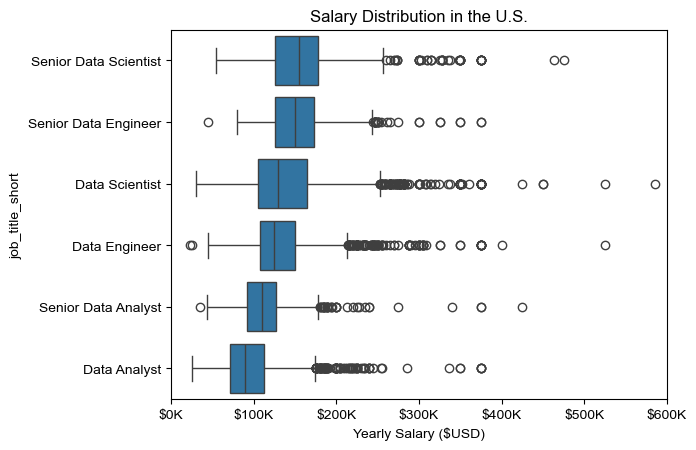

In [22]:
sns.boxplot(data=df_US_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')

plt.title('Salary Distribution in the U.S.')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter( lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()

#### Investigate Median Salary Vs Skill for Data Analysts

In [23]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [24]:
df_DA_US = df_DA_US.explode('job_skills')

df_DA_US[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [25]:
df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_top_pay

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


In [26]:
df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills

,count,median
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0
...,...,...
couchbase,1,160515.0
chainer,1,100000.0
chef,1,85000.0


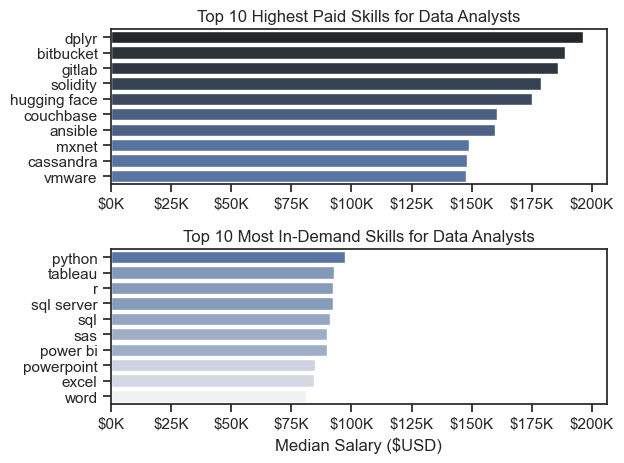

In [27]:
df_DA_US = df_DA_US.explode('job_skills')

df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)
df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

fig, ax = plt.subplots(2,1)

sns.set_theme(style="ticks")

# top 10 highest paid skills for data analysts
sns.barplot(data=df_DA_top_pay, x = 'median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r') # _r to reverse the coloring
# df_DA_top_pay[::-1].plot(kind='barh', y = 'median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[0].legend().remove()

sns.barplot(data=df_DA_skills, x = 'median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='light:b')
# df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())
ax[1].legend().remove()

fig.tight_layout()
plt.show()

In [28]:
# Rebuild df_DA_skills_high_demand for the optimal-skills scatter plot
# Uses the same df_DA_US (already exploded on job_skills) from your Q3 cell

# 1. Total number of DA job postings, for the % calculation.
#    If you have a unique posting identifier column (e.g. 'job_id'), use that instead of len().
total_DA_jobs = len(df_DA_US)  # <-- replace with df_DA_US['job_id'].nunique() if you have a job_id column

# 2. Skill counts + median salary per skill, computed the same way as your df_DA_skills/df_DA_top_pay cell above
df_DA_skills_high_demand = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).reset_index()
df_DA_skills_high_demand = df_DA_skills_high_demand.rename(columns={'median': 'median_salary'})

# 3. Convert raw count into a percentage of all DA postings
df_DA_skills_high_demand['skill_percent'] = df_DA_skills_high_demand['count'] / total_DA_jobs * 100

# 4. Filter out rare/noisy skills so the chart isn't cluttered (matches the ~5%+ range in your chart)
df_DA_skills_high_demand = df_DA_skills_high_demand[df_DA_skills_high_demand['skill_percent'] > 5]

# 5. Add technology category for coloring the scatter plot (matches your legend: programming, analyst_tools, databases, cloud)
skill_categories = {
    'python': 'programming', 'sql': 'programming', 'r': 'programming', 'go': 'programming', 'sas': 'programming',
    'tableau': 'analyst_tools', 'power bi': 'analyst_tools', 'excel': 'analyst_tools',
    'powerpoint': 'analyst_tools', 'word': 'analyst_tools',
    'sql server': 'databases', 'oracle': 'cloud',
}
df_DA_skills_high_demand['technology'] = df_DA_skills_high_demand['job_skills'].map(skill_categories)

df_DA_skills_high_demand.head()

,job_skills,count,median_salary,skill_percent,technology
42,excel,1808,84392.0,10.366972,analyst_tools
108,python,1431,97500.0,8.205275,programming
111,r,893,92500.0,5.120413,programming
119,sas,926,90000.0,5.309633,programming
137,sql,2508,91000.0,14.380734,programming


In [34]:
# Rebuild df_DA_skills_high_demand for the optimal-skills scatter plot
# Uses the same df_DA_US (already exploded on job_skills) from your Q3 cell

# 1. Total number of DA job postings, for the % calculation.
#    No unique job_id column exists, so reconstruct original posting count by
#    dropping duplicates on everything except job_skills (which is what got exploded).
total_DA_jobs = df_DA_US.drop(columns='job_skills').drop_duplicates().shape[0]

# 2. Skill counts + median salary per skill, computed the same way as your df_DA_skills/df_DA_top_pay cell above
df_DA_skills_high_demand = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).reset_index()
df_DA_skills_high_demand = df_DA_skills_high_demand.rename(columns={'median': 'median_salary'})

# 3. Convert raw count into a percentage of all DA postings
df_DA_skills_high_demand['skill_percent'] = df_DA_skills_high_demand['count'] / total_DA_jobs * 100

# 4. Filter out rare/noisy skills so the chart isn't cluttered (matches the ~5%+ range in your chart)
df_DA_skills_high_demand = df_DA_skills_high_demand[df_DA_skills_high_demand['skill_percent'] > 5]

# 5. Add technology category for coloring the scatter plot (matches your legend: programming, analyst_tools, databases, cloud)
skill_categories = {
    'python': 'programming', 'sql': 'programming', 'r': 'programming', 'go': 'programming', 'sas': 'programming',
    'tableau': 'analyst_tools', 'power bi': 'analyst_tools', 'excel': 'analyst_tools',
    'powerpoint': 'analyst_tools', 'word': 'analyst_tools',
    'sql server': 'databases', 'oracle': 'cloud',
}
df_DA_skills_high_demand['technology'] = df_DA_skills_high_demand['job_skills'].map(skill_categories)

df_DA_skills_high_demand.head()

,job_skills,count,median_salary,skill_percent,technology
42,excel,1808,84392.00,41.572775,analyst_tools
54,go,224,90000.00,5.150609,programming
94,oracle,274,96923.75,6.300299,cloud
103,power bi,838,90000.00,19.268797,analyst_tools
104,powerpoint,462,85000.00,10.623132,analyst_tools


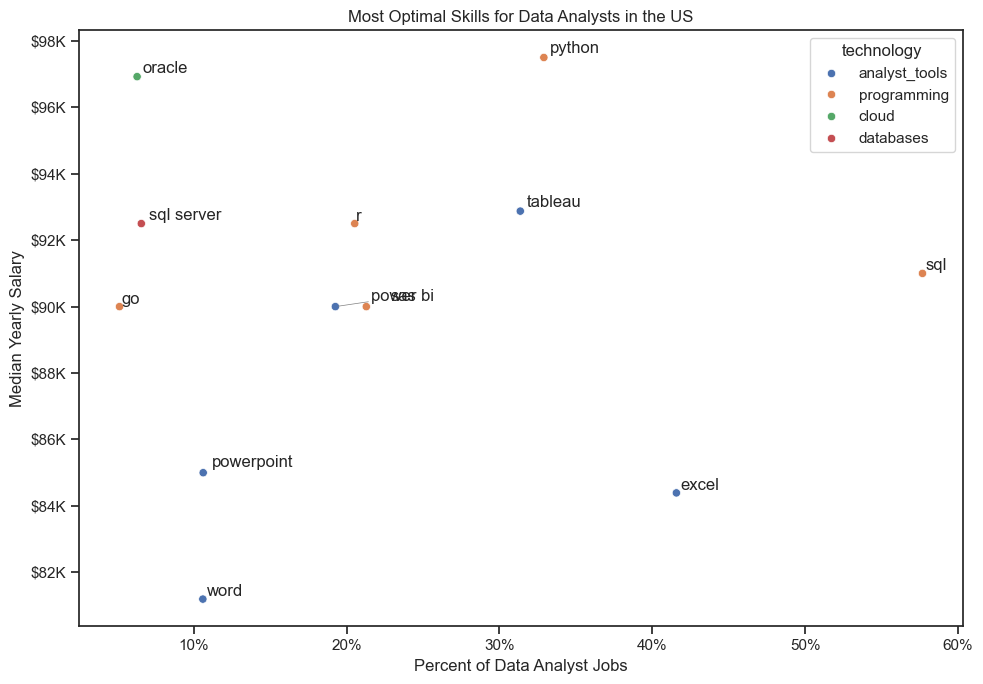

In [35]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=df_DA_skills_high_demand,
    x='skill_percent',
    y='median_salary',
    hue='technology',
    ax=ax
)

# Label each point with its skill name
texts = []
for i, row in df_DA_skills_high_demand.iterrows():
    texts.append(plt.text(row['skill_percent'], row['median_salary'], row['job_skills']))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.set_title('Most Optimal Skills for Data Analysts in the US')
ax.set_xlabel('Percent of Data Analyst Jobs')
ax.set_ylabel('Median Yearly Salary')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K'))

plt.tight_layout()
plt.show()